# YOLO26x-cls Fine-Tuning — Bangladesh Rice Leaf Disease (10 classes)

**Fixed / trimmed version.** Original notebook's Section 8 added a "run yolo26x-cls" section but
never actually defined or trained the `x` variant — it only tried to *recover* old n/s/m results
from disk, then referenced `all_results["yolo26x-cls"]`, which didn't exist -> `KeyError`.
The final packaging cells also referenced `REPORT_DIR` and `comparison_df`, which were never
defined anywhere in the notebook -> `NameError`.

This version trains **only `yolo26x-cls`**, self-contained, no dependency on prior n/s/m runs.

**How to run (fresh Kaggle session, GPU on):** Run every cell top to bottom, in order, once.
That's it — there is nothing to skip and nothing to run twice. Cell 4 has the one path you must
confirm (`KAGGLE_INPUT`).

## 1. Install

In [4]:
!pip -q install "ultralytics>=8.3,<9" onnx onnxslim tensorflow 2>&1 | tail -n 5


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.4 MB/s eta 0:00:00


## 2. Environment Fingerprint

In [5]:
import platform, subprocess, json, sys
import torch
import ultralytics

def get_gpu_info():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"]
        ).decode().strip()
        return out
    except Exception as e:
        return f"no GPU / nvidia-smi failed: {e}"

fingerprint = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    "gpu": get_gpu_info(),
}
print(json.dumps(fingerprint, indent=2))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
{
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "ultralytics": "8.4.138",
  "torch": "2.10.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "cudnn_version": 91002,
  "gpu": "Tesla T4, 15360 MiB, 580.159.04\nTesla T4, 15360 MiB, 580.159.04"
}


## 3. Paths & Global Configuration

Kaggle mounts the dataset read-only under `/kaggle/input/...` and auto-unzips `Rice_224.zip`.
`REPORT_DIR` was missing in the original notebook (referenced later but never created) — added here.

In [6]:
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List

KAGGLE_INPUT = Path("/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224")  # <-- confirm this matches your mounted path

WORKING_DIR = Path("/kaggle/working")
RUNS_DIR = WORKING_DIR / "runs"
BACKUP_DIR = WORKING_DIR / "backups"
ARCHIVE_DIR = WORKING_DIR / "archives"
REPORT_DIR = WORKING_DIR / "report"

for d in (RUNS_DIR, BACKUP_DIR, ARCHIVE_DIR, REPORT_DIR, REPORT_DIR / "figures", REPORT_DIR / "metrics"):
    d.mkdir(parents=True, exist_ok=True)

# Alphabetical order = label index, matches classes.txt / ImageFolder.
CLASSES = [
    "Rice__Bacterial_Leaf_Blight",
    "Rice__Brown_Spot",
    "Rice__Healthy_Leaf",
    "Rice__Leaf_Blast",
    "Rice__Leaf_Scald",
    "Rice__Narrow_Brown_Leaf_Spot",
    "Rice__Rice_Hispa",
    "Rice__Sheath_Blight",
    "Rice__Turongo",
    "Others",
]
NUM_CLASSES = len(CLASSES)

SHORT_LABELS = {
    "Rice__Bacterial_Leaf_Blight": "BLB",
    "Rice__Brown_Spot": "Brown Spot",
    "Rice__Healthy_Leaf": "Healthy",
    "Rice__Leaf_Blast": "Leaf Blast",
    "Rice__Leaf_Scald": "Leaf Scald",
    "Rice__Narrow_Brown_Leaf_Spot": "Narrow Brown",
    "Rice__Rice_Hispa": "Hispa",
    "Rice__Sheath_Blight": "Sheath Blight",
    "Rice__Turongo": "Turongo",
    "Others": "Others",
}

print(f"Dataset root: {KAGGLE_INPUT}")
print(f"Exists: {KAGGLE_INPUT.exists()}")
for split in ("train", "val", "test"):
    d = KAGGLE_INPUT / split
    print(f"  {split}: exists={d.exists()}", "" if not d.exists() else f"classes_found={len(list(d.iterdir()))}")


Dataset root: /kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224
Exists: True
  train: exists=True classes_found=10
  val: exists=True classes_found=10
  test: exists=True classes_found=10


## 4. Stats helper (95% binomial CI for small-class recall)

In [7]:
import math

def binomial_ci(p_hat: float, n: int, z: float = 1.96):
    if n == 0:
        return (float("nan"), float("nan")), float("nan")
    se = math.sqrt(max(p_hat * (1 - p_hat), 0) / n)
    return (max(0.0, p_hat - z * se), min(1.0, p_hat + z * se)), se


## 5. Run Configuration — yolo26x-cls only

Largest classify head, 120 epochs, early stopping via `patience=20`. Batch dropped to 16 —
x-cls params are much larger than m; 32 risks OOM on a T4 16GB.

In [8]:
@dataclass
class VariantConfig:
    name: str                      # e.g. "yolo26x-cls"
    weights: str                   # ImageNet-pretrained checkpoint to start from
    epochs: int = 120
    imgsz: int = 224
    batch: int = 16
    patience: int = 20
    save_period: int = 5
    optimizer: str = "AdamW"
    lr0: float = 0.001
    weight_decay: float = 0.0005
    warmup_epochs: float = 3.0
    cos_lr: bool = True
    label_smoothing: float = 0.05
    hsv_h: float = 0.015
    hsv_s: float = 0.7
    hsv_v: float = 0.4
    fliplr: float = 0.5
    flipud: float = 0.0
    scale: float = 0.5
    erasing: float = 0.4
    auto_augment: str = "randaugment"
    amp: bool = True
    seed: int = 0
    deterministic: bool = False
    cache: bool = False            # Kaggle RAM-limited; keep False
    device: int = 0

VARIANT = VariantConfig(name="yolo26x-cls", weights="yolo26x-cls.pt", epochs=120, batch=16, patience=20)
print(VARIANT)


VariantConfig(name='yolo26x-cls', weights='yolo26x-cls.pt', epochs=120, imgsz=224, batch=16, patience=20, save_period=5, optimizer='AdamW', lr0=0.001, weight_decay=0.0005, warmup_epochs=3.0, cos_lr=True, label_smoothing=0.05, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, fliplr=0.5, flipud=0.0, scale=0.5, erasing=0.4, auto_augment='randaugment', amp=True, seed=0, deterministic=False, cache=False, device=0)


## 6. Train / Evaluate / Export Pipeline

Same pipeline as the rest of the notebook (train_variant): resume-aware, evaluates val+test with an
independent sklearn report + ECE + per-class 95% CI, exports ONNX/TFLite/TorchScript/OpenVINO,
backs up the run dir, and zips it into `archives/yolo26x-cls.zip`.

In [9]:
import json, shutil, time
import numpy as np
from ultralytics import YOLO
from sklearn.metrics import classification_report, f1_score

def resolve_resume(variant: VariantConfig):
    """Return (weights_path, resume_bool). Resumes from last.pt if a prior run exists."""
    candidate_last = RUNS_DIR / "classify" / variant.name / "weights" / "last.pt"
    if candidate_last.exists():
        print(f"[{variant.name}] found existing last.pt -> resuming")
        return str(candidate_last), True
    return variant.weights, False


def expected_calibration_error(confidences: np.ndarray, correct: np.ndarray, n_bins: int = 15) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc = correct[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)


def run_split_eval(model: YOLO, data_root: str, split: str, variant_name: str):
    metrics = model.val(data=data_root, split=split, imgsz=224, plots=True,
                         project=str(RUNS_DIR / "classify"), name=f"{variant_name}_{split}_eval")

    split_dir = Path(data_root) / split
    y_true, y_pred, confidences = [], [], []
    for cls_idx, cls_name in enumerate(CLASSES):
        cls_dir = split_dir / cls_name
        if not cls_dir.exists():
            continue
        img_paths = list(cls_dir.glob("*.jpg"))
        if not img_paths:
            continue
        preds = model.predict(img_paths, imgsz=224, verbose=False, device=0)
        for p in preds:
            y_true.append(cls_idx)
            top1 = int(p.probs.top1)
            y_pred.append(top1)
            confidences.append(float(p.probs.data[top1]))

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    conf_arr = np.array(confidences)
    correct_arr = (y_true_arr == y_pred_arr).astype(float)

    report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    ece = expected_calibration_error(conf_arr, correct_arr)

    per_class_ci = {}
    for cls_idx, cls_name in enumerate(CLASSES):
        n_cls = int((y_true_arr == cls_idx).sum())
        if n_cls == 0:
            continue
        recall = report[cls_name]["recall"]
        (lo, hi), se = binomial_ci(recall, n_cls)
        per_class_ci[cls_name] = {"n": n_cls, "recall": recall, "se": se, "ci95": [lo, hi]}

    return {
        "top1": float(metrics.top1),
        "top5": float(metrics.top5),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "ece": ece,
        "classification_report": report,
        "per_class_ci": per_class_ci,
    }, metrics


def export_and_validate(model: YOLO, variant_name: str, data_root: str):
    export_results = {}
    formats = [
        ("onnx", {"format": "onnx", "imgsz": 224, "simplify": True}),
        ("tflite", {"format": "litert", "imgsz": 224, "int8": False}),
        ("tflite_int8", {"format": "litert", "imgsz": 224, "int8": True, "data": data_root}),
        ("torchscript", {"format": "torchscript", "imgsz": 224}),
        ("openvino", {"format": "openvino", "imgsz": 224}),
    ]
    for fmt_name, kwargs in formats:
        try:
            t0 = time.time()
            path = model.export(**kwargs)
            export_results[fmt_name] = {"path": str(path), "export_seconds": round(time.time() - t0, 2)}
        except Exception as e:
            export_results[fmt_name] = {"error": str(e)}
            print(f"[{variant_name}] export to {fmt_name} failed: {e}")

    if "path" in export_results.get("onnx", {}):
        try:
            onnx_model = YOLO(export_results["onnx"]["path"])
            onnx_metrics = onnx_model.val(data=data_root, split="test", imgsz=224,
                                           project=str(RUNS_DIR / "classify"),
                                           name=f"{variant_name}_onnx_test_eval")
            export_results["onnx"]["test_top1"] = float(onnx_metrics.top1)
        except Exception as e:
            export_results["onnx"]["validation_error"] = str(e)

    if "path" in export_results.get("tflite_int8", {}):
        p = Path(export_results["tflite_int8"]["path"])
        if p.exists():
            export_results["tflite_int8"]["size_MB"] = round(p.stat().st_size / (1024 * 1024), 3)

    return export_results


def train_variant(variant: VariantConfig, data_root: str = str(KAGGLE_INPUT)) -> dict:
    print(f"\n{'=' * 70}\n[{variant.name}] starting\n{'=' * 70}")

    weights, resume = resolve_resume(variant)
    model = YOLO(weights)

    train_kwargs = dict(
        data=data_root,
        epochs=variant.epochs,
        imgsz=variant.imgsz,
        batch=variant.batch,
        patience=variant.patience,
        save_period=variant.save_period,
        optimizer=variant.optimizer,
        lr0=variant.lr0,
        weight_decay=variant.weight_decay,
        warmup_epochs=variant.warmup_epochs,
        cos_lr=variant.cos_lr,
        label_smoothing=variant.label_smoothing,
        hsv_h=variant.hsv_h, hsv_s=variant.hsv_s, hsv_v=variant.hsv_v,
        fliplr=variant.fliplr, flipud=variant.flipud, scale=variant.scale,
        erasing=variant.erasing, auto_augment=variant.auto_augment,
        amp=variant.amp, seed=variant.seed, deterministic=variant.deterministic,
        cache=variant.cache, device=variant.device,
        project=str(RUNS_DIR / "classify"), name=variant.name, exist_ok=True,
    )
    if resume:
        model.train(resume=True)
    else:
        model.train(**train_kwargs)

    save_dir = Path(model.trainer.save_dir)
    best_pt = save_dir / "weights" / "best.pt"
    last_pt = save_dir / "weights" / "last.pt"

    best_model = YOLO(str(best_pt))

    val_metrics, _ = run_split_eval(best_model, data_root, "val", variant.name)
    test_metrics, _ = run_split_eval(best_model, data_root, "test", variant.name)
    export_results = export_and_validate(best_model, variant.name, data_root)

    test_metrics_full = {
        "variant": variant.name,
        "val": val_metrics,
        "test": test_metrics,
        "exports": export_results,
        "params": sum(p.numel() for p in best_model.model.parameters()),
        "config": asdict(variant),
    }

    metrics_path = save_dir / "test_metrics.json"
    metrics_path.write_text(json.dumps(test_metrics_full, indent=2))

    backup_target = BACKUP_DIR / variant.name
    if backup_target.exists():
        shutil.rmtree(backup_target)
    shutil.copytree(save_dir, backup_target)
    shutil.copy2(best_pt, WORKING_DIR / f"{variant.name}_best.pt")
    shutil.copy2(last_pt, WORKING_DIR / f"{variant.name}_last.pt")

    archive_path = shutil.make_archive(str(ARCHIVE_DIR / variant.name), "zip", root_dir=backup_target)
    print(f"[{variant.name}] done. Archive: {archive_path}")

    return test_metrics_full


## 7. Run it (this is the actual training cell — takes a while)

In [10]:
all_results = {}
result = train_variant(VARIANT)
all_results[VARIANT.name] = result

(WORKING_DIR / "all_results.json").write_text(json.dumps(all_results, indent=2))
print("\nDone:", VARIANT.name)
print(f"test top1={result['test']['top1']:.4f}  macro_f1={result['test']['macro_f1']:.4f}  ece={result['test']['ece']:.4f}")



[yolo26x-cls] starting
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224, degrees=0.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/120      1.95G      1.012          8        224: 100% ━━━━━━━━━━━━ 234/234 9.7it/s 24.1s<0.1ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 26/26 19.3it/s 1.3s0.1s
                   all      0.732       0.99

      Epoch    GPU_mem       loss  Instances       Size
      3/120      1.95G      1.008          8        224: 100% ━━━━━━━━━━━━ 234/234 9.2it/s 25.5s<0.2ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 26/26 18.5it/s 1.4s0.1s
                   all      0.713      0.988

      Epoch    GPU_mem       loss  Instances       Size
      4/120      1.96G     0.9341          8        224: 100% ━━━━━━━━━━━━ 234/234 11.1it/s 21.0s.2sss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 26/26 16.9it/s 1.5s0.1s
                   all      0.704      0.988

      Epoch    GPU_mem       loss  Instances       Size
      5/120      1.96G     0.8788          8        224: 100% ━━━━━━━━━━━━ 234/234 11.1it/s 21.1s0.2ss
               cla

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


...

LiteRT: applying static quantization (int8 weights + int8 activations)...


/usr/local/lib/python3.12/dist-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Generating Quantization Parameters::  57%|█████▋    | 187/328 [00:00<00:00, 1780.83it/s]/usr/local/lib/python3.12/dist-packages/ai_edge_quantizer/algorithms/uniform_quantize/uniform_quantize_tensor.py:109: RuntimeWarning: invalid value encountered in cast
  return tensor.astype(qtype, copy=False)
Applying Transformations to tensors:: 100%|██████████| 518/518 [00:00<00:00, 24915.13it/s]


Model name: /kaggle/working/runs/classify/yolo26x-cls/weights/best_int8.tflite
Original model size: 108.29 MiB
Quantized model size: 27.82 MiB
Quantization Ratio: 0.26 (3.9x smaller)
Total time: 312.64 ms
LiteRT: export success ✅ 384.3s, saved as '/kaggle/working/runs/classify/yolo26x-cls/weights/best_int8.tflite' (27.8 MB)

Export complete (384.6s)
Results saved to /kaggle/working/runs/classify/yolo26x-cls/weights/best_int8.tflite
Predict:         yolo predict task=classify model=/kaggle/working/runs/classify/yolo26x-cls/weights/best_int8.tflite imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/runs/classify/yolo26x-cls/weights/best_int8.tflite imgsz=224 data=/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224  
Visualize:       https://netron.app
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/classify/yolo26x-cls/weights/best.pt' with input shape (1, 3, 224, 224) BCHW 

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


OpenVINO: export success ✅ 5.9s, saved as '/kaggle/working/runs/classify/yolo26x-cls/weights/best_openvino_model/' (108.4 MB)

Export complete (6.3s)
Results saved to /kaggle/working/runs/classify/yolo26x-cls/weights/best_openvino_model
Predict:         yolo predict task=classify model=/kaggle/working/runs/classify/yolo26x-cls/weights/best_openvino_model/ imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/runs/classify/yolo26x-cls/weights/best_openvino_model/ imgsz=224 data=/kaggle/input/datasets/khanraiyanibnereza/rice-224/Rice_224  
Visualize:       https://netron.app
Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Loading /kaggle/working/runs/classify/yolo26x-cls/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 253ms
Prepared 1 package in 1.78s
Installed 1 package in 116

## 8. Per-class breakdown — yolo26x-cls (test set)

Full precision/recall/F1/support per class, sorted weakest-recall-first, with 95% CI on the small classes (Turongo n=34, Narrow Brown n=52).

In [11]:
import pandas as pd

x_report = all_results["yolo26x-cls"]["test"]["classification_report"]
x_ci = all_results["yolo26x-cls"]["test"]["per_class_ci"]

rows = []
for cls in CLASSES:
    r = x_report[cls]
    ci = x_ci.get(cls, {})
    rows.append({
        "class": SHORT_LABELS[cls],
        "support": int(r["support"]),
        "precision": round(r["precision"], 4),
        "recall": round(r["recall"], 4),
        "f1": round(r["f1-score"], 4),
        "recall_95ci_lo": round(ci.get("ci95", [float("nan"), float("nan")])[0], 4),
        "recall_95ci_hi": round(ci.get("ci95", [float("nan"), float("nan")])[1], 4),
    })

x_breakdown = pd.DataFrame(rows).sort_values("recall")
x_breakdown.to_csv(REPORT_DIR / "metrics" / "yolo26x-cls_per_class_breakdown.csv", index=False)

print(f"yolo26x-cls test: top1={all_results['yolo26x-cls']['test']['top1']:.4f}  "
      f"macro_f1={all_results['yolo26x-cls']['test']['macro_f1']:.4f}  "
      f"ece={all_results['yolo26x-cls']['test']['ece']:.4f}")
x_breakdown


yolo26x-cls test: top1=0.8964  macro_f1=0.0149  ece=0.9195


,class,support,precision,recall,f1,recall_95ci_lo,recall_95ci_hi
0,BLB,55,0.0000,0.0000,0.0000,0.0000,0.0000
2,Healthy,135,0.0000,0.0000,0.0000,0.0000,0.0000
6,Hispa,55,0.0000,0.0000,0.0000,0.0000,0.0000
8,Turongo,34,0.0000,0.0000,0.0000,0.0000,0.0000
9,Others,90,0.0000,0.0000,0.0000,0.0000,0.0000
7,Sheath Blight,58,0.0189,0.0172,0.0180,0.0000,0.0507
1,Brown Spot,57,0.0161,0.0175,0.0168,0.0000,0.0516
4,Leaf Scald,114,0.0203,0.0263,0.0229,0.0000,0.0557
5,Narrow Brown,52,0.0172,0.0385,0.0238,0.0000,0.0907
3,Leaf Blast,151,0.0694,0.0662,0.0678,0.0266,0.1059


## 9. Training curve (loss + top1 accuracy per epoch)

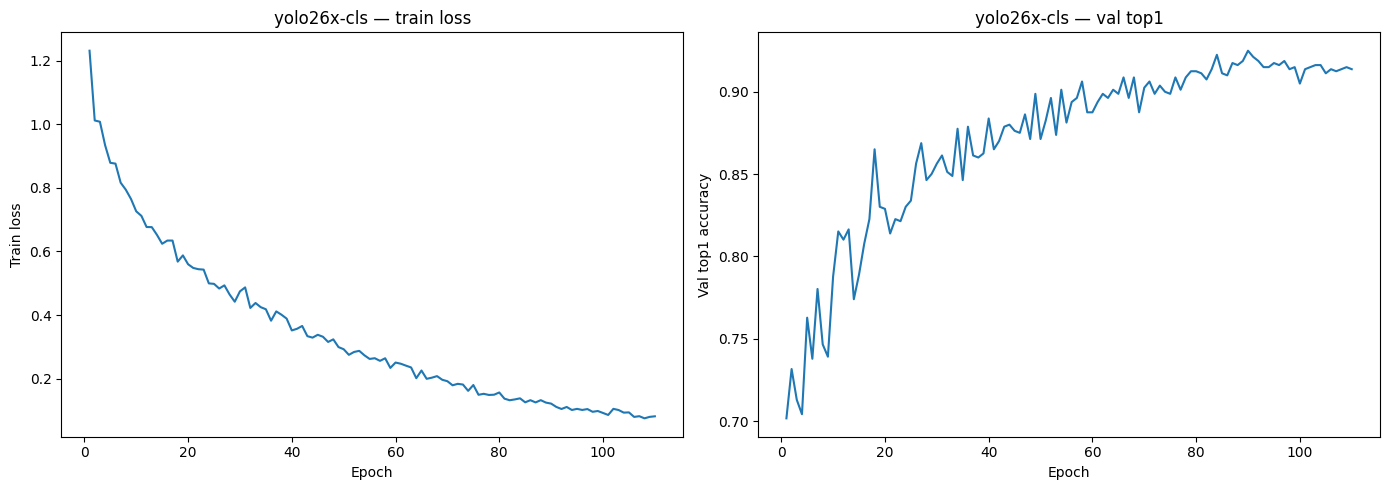

In [12]:
import matplotlib.pyplot as plt

def load_results_csv(variant_name: str) -> pd.DataFrame:
    csv_path = RUNS_DIR / "classify" / variant_name / "results.csv"
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    return df

def find_col(df: pd.DataFrame, *substrings) -> str:
    for c in df.columns:
        if all(s.lower() in c.lower() for s in substrings):
            return c
    return None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df = load_results_csv(VARIANT.name)
epoch_col = find_col(df, "epoch") or df.columns[0]
loss_col = find_col(df, "train", "loss")
top1_col = find_col(df, "top1") or find_col(df, "accuracy_top1")

if loss_col:
    axes[0].plot(df[epoch_col], df[loss_col])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss"); axes[0].set_title(f"{VARIANT.name} — train loss")

if top1_col:
    axes[1].plot(df[epoch_col], df[top1_col])
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val top1 accuracy"); axes[1].set_title(f"{VARIANT.name} — val top1")

plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "yolo26x-cls_training_curves.png", dpi=150)
plt.show()


## 10. Package & Download

Bundles the important stuff into one zip: `best.pt`, `last.pt`, all exports (ONNX/TFLite/TorchScript/OpenVINO),
`test_metrics.json`, `all_results.json`, the per-class breakdown CSV, training-curve PNG, and the
native Ultralytics plots (`results.png`, `confusion_matrix.png`, `confusion_matrix_normalized.png`, `args.yaml`).